In [1]:
import pickle
import re
import random

import numpy as np
from scipy.interpolate import interp1d

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import pymc as pm

import matplotlib.pyplot as plt
import arviz as az

/Users/mariamelsayed/anaconda3/envs/bayes_new/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
# Setting random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)  

## Data Preparation

In [3]:
# Loading data

batDict = pickle.load(open('../data/batDict.pkl', 'rb'))
best_polGrp = np.load('../data/best_polGrp.npy')
# best_polGrp = np.load('../data/best_polGrp_km.npy')

In [4]:
cellIds = list(batDict.keys())
n_cells = len(cellIds)

In [5]:
def parseProtocol(policy):
    policy = policy.replace('-newstructure', '').strip()

    if not re.search(r'[C%]', policy, re.IGNORECASE):
        rates = [float(x) for x in policy.split('-') if x.strip()]
        return ('C', rates)  # Format C

    m = re.match(r'([\d.]+)[Cc]\(([\d.]+)%\)-([\d.]+)[Cc]?', policy)
    if m:
        return ('B', [float(m.group(1)), float(m.group(2)) / 100, float(m.group(3))])

    raise ValueError(f"Cannot parse protocol: '{policy}'")

def parse_avg_crate(charge_policy):
    fmt, vals = parseProtocol(charge_policy)
    if fmt == 'C':
        return sum(vals) * 0.20 + 1.0 * 0.20
    cc1, bp, cc2 = vals
    return cc1 * bp + cc2 * (0.80 - bp) + 1.0 * 0.20

avgCrates = np.array([parse_avg_crate(batDict[cid]['charge_policy']) for cid in cellIds])

In [6]:
policy_list      = sorted(set(batDict[c]['charge_policy'] for c in cellIds))
policy_to_idx    = {p: i for i, p in enumerate(policy_list)}
cellPolicyId     = np.array([policy_to_idx[batDict[c]['charge_policy']]
                              for c in cellIds])

final_cellGrp  = best_polGrp[cellPolicyId]

N_GROUPS = 8

In [7]:
# Feature extraction

cycle_early = 10
cycle_late = 100

def compute_F1_F2(cell):
    '''
    Feature extraction following paper
    ---
    F1: Variance of discharge \delta Q(V) between 10th and 100th cycles
    F2:
    '''
    
    early = cell['cycles'][str(cycle_early)]
    late  = cell['cycles'][str(cycle_late)]
    
    V_early, Qd_early = early['V'], early['Qd']
    V_late,  Qd_late  = late['V'],  late['Qd']

    # Common voltage grid
    v_min = max(V_early.min(), V_late.min())
    v_max = min(V_early.max(), V_late.max())
    if v_min >= v_max:
        return np.nan, np.nan
    v_grid = np.linspace(v_min, v_max, 500)

    f_early = interp1d(V_early, Qd_early, bounds_error=False, fill_value=np.nan)
    f_late  = interp1d(V_late,  Qd_late,  bounds_error=False, fill_value=np.nan)
    
    delta_Q = f_late(v_grid) - f_early(v_grid)
    delta_Q = delta_Q[~np.isnan(delta_Q)]
    
    if len(delta_Q) == 0:
        return np.nan, np.nan
    
    return np.var(delta_Q), np.min(delta_Q)

In [8]:
F1_arr = np.zeros(n_cells)
F2_arr = np.zeros(n_cells)
F3_arr = np.zeros(n_cells)

for i, cid in enumerate(cellIds):
    
    cell = batDict[cid]
    
    # F3: discharge capacity at cycle 2 (index 2 because cycle 1 is index 0)
    F3_arr[i] = cell['summary']['QD'][2]   # in Ah
    
    f1, f2 = compute_F1_F2(cell)
    F1_arr[i] = f1
    F2_arr[i] = f2

In [9]:
def cell_lifetime_days(cell):
    
    cycle_durations = []
    
    for ck in cell['cycles']:
        t = cell['cycles'][ck]['t']
        if len(t) > 1:
            cycle_durations.append(t[-1] - t[0])
    
    if not cycle_durations:
        return np.nan
    
    return np.cumsum(cycle_durations)[-1] / 60 / 24

In [10]:
# mean avg c-rate per group
group_g = np.array([avgCrates[final_cellGrp == g].mean() for g in range(N_GROUPS)])

In [11]:
X = np.column_stack([F1_arr, F2_arr, F3_arr])
y_days = np.array([cell_lifetime_days(batDict[cid]) for cid in cellIds])

In [12]:
print(f"Number of cells: {len(X)}")
print(f"Number of groups: {np.unique(final_cellGrp)}")

Number of cells: 169
Number of groups: [0 1 2 3 4 5 6 7]


## K-Fold Cross Validation

In [13]:
def build_hbm_model(X_train_scaled, y_train_scaled, groups_train_idx, group_g_train, N_GROUPS):

    n_features = X_train_scaled.shape[1]

    with pm.Model() as BH_model:

        ######################################
        # Level 3: Hyperprior gamma
        ######################################
        gamma_intercept = pm.Normal('gamma_intercept', mu=0, sigma=10, shape=n_features+1)
        gamma_slope = pm.Normal('gamma_slope', mu=0, sigma=10, shape=n_features+1)

        ######################################
        # Level 2: Group prior
        ######################################

        # Random effect standard deviation
        sigma_theta = pm.Exponential('sigma_theta', 1.0, shape=n_features+1)
        
        # Non‑centered offsets 
        theta_raw = pm.Normal('theta_raw', mu=0, sigma=1, shape=(N_GROUPS, n_features+1))
        
        # Mean of theta_j
        mu_theta = gamma_intercept + gamma_slope * group_g_train[:, None]
        
        # Group‑specific coefficients
        theta = pm.Deterministic('theta', mu_theta + sigma_theta * theta_raw)

        ######################################
        # Level 1: Observation model
        ######################################
        sigma_y = pm.Exponential('sigma_y', 1.0)
        mu = theta[groups_train_idx, 0] + pm.math.sum(theta[groups_train_idx, 1:] * X_train_scaled, axis=1)
        y_obs_scaled = pm.Normal('y_obs', mu=mu, sigma=sigma_y, observed=y_train_scaled)

    return BH_model

def run_hbm_cv_fold(X_train, y_train, groups_train, group_g_train, X_test, y_test, groups_test):
    """Run HBM on one CV fold."""
    # Standardize within fold
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    
    # Re-index groups
    unique_groups = np.unique(groups_train)
    group_map = {old: new for new, old in enumerate(unique_groups)}
    groups_train_idx = np.array([group_map[g] for g in groups_train])
    groups_test_idx = np.array([group_map.get(g, -1) for g in groups_test])
    
    group_g_train_fold = group_g[unique_groups]
    
    # Build and sample
    with build_hbm_model(X_train_scaled, y_train_scaled, groups_train_idx, 
                         group_g_train_fold, len(unique_groups)) as model:
        trace = pm.sample(draws=2000, tune=2000, chains=2, cores=1, 
                          random_seed=42, progressbar=False)
        ppc = pm.sample_posterior_predictive(trace, predictions=True, random_seed=42)
    
    # Predict
    theta_mean = trace.posterior['theta'].mean(dim=['chain', 'draw']).values
    mu_test = theta_mean[groups_test_idx, 0] + np.sum(theta_mean[groups_test_idx, 1:] * X_test_scaled, axis=1)
    y_pred_scaled = mu_test
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    return y_test, y_pred, rmse, mape, trace

In [14]:
n_folds = 5
n_repeats = 4

hbm_rmse_list = []
hbm_mape_list = []
ridge_rmse_list = []
ridge_mape_list = []
ridge_group_rmse_list = []
ridge_group_mape_list = []

for repeat in range(n_repeats):
    print(f"\nRepeat {repeat + 1}/{n_repeats}")
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED+repeat)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"  Fold {fold + 1}/{n_folds}", end=" ", flush=True)
        
        # Split TRAIN ONLY
        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = y_days[train_idx]
        y_val_fold = y_days[val_idx]
        groups_train_fold = final_cellGrp[train_idx]
        groups_val_fold = final_cellGrp[val_idx]
        
        # Standardize for Ridge
        scaler_X_fold = StandardScaler()
        X_train_ridge = scaler_X_fold.fit_transform(X_train_fold)
        X_val_ridge = scaler_X_fold.transform(X_val_fold)
        
        # Ridge without group feature
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_train_ridge, y_train_fold)
        y_pred_ridge = ridge.predict(X_val_ridge)

        ridge_rmse_list.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_ridge)))
        ridge_mape_list.append(mean_absolute_percentage_error(y_val_fold, y_pred_ridge) * 100)
        
        # Ridge with group feature
        group_g_train_cell = group_g[groups_train_fold]
        group_g_val_cell = group_g[groups_val_fold]

        X_train_ridge_group = np.column_stack([X_train_ridge, group_g_train_cell])
        X_val_ridge_group = np.column_stack([X_val_ridge, group_g_val_cell])

        ridge_group = Ridge(alpha=1.0)
        ridge_group.fit(X_train_ridge_group, y_train_fold)
        y_pred_ridge_group = ridge_group.predict(X_val_ridge_group)

        ridge_group_rmse_list.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_ridge_group)))
        ridge_group_mape_list.append(mean_absolute_percentage_error(y_val_fold, y_pred_ridge_group) * 100)
        
        _, _, rmse_hbm, mape_hbm, _ = run_hbm_cv_fold(
            X_train_fold, y_train_fold, groups_train_fold, group_g,
            X_val_fold, y_val_fold, groups_val_fold
        )
        if not np.isnan(rmse_hbm):
            hbm_rmse_list.append(rmse_hbm)
            hbm_mape_list.append(mape_hbm)
            print(f"HBM: {rmse_hbm:.2f}", end=" ")
        
        print(f"Ridge: {ridge_rmse_list[-1]:.2f}", end=" ")
        print(f"Ridge+G: {ridge_group_rmse_list[-1]:.2f}")


Repeat 1/4
  Fold 1/5 

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [gamma_intercept, gamma_slope, sigma_theta, theta_raw, sigma_y]
Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 74 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


Output()

HBM: 6.29 Ridge: 6.47 Ridge+G: 5.72
  Fold 2/5 

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [gamma_intercept, gamma_slope, sigma_theta, theta_raw, sigma_y]
Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


...

Output()

HBM: 4.80 Ridge: 6.92 Ridge+G: 5.34
  Fold 5/5 

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [gamma_intercept, gamma_slope, sigma_theta, theta_raw, sigma_y]
Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 97 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


Output()

HBM: 19.29 Ridge: 18.91 Ridge+G: 18.99


In [15]:
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

print(f"\nRidge (no group feature):")
print(f"  RMSE: median={np.median(ridge_rmse_list):.2f} days, mean={np.mean(ridge_rmse_list):.2f} days")
print(f"  MAPE: median={np.median(ridge_mape_list):.1f}%, mean={np.mean(ridge_mape_list):.1f}%")

print(f"\nRidge (with group feature):")
print(f"  RMSE: median={np.median(ridge_group_rmse_list):.2f} days, mean={np.mean(ridge_group_rmse_list):.2f} days")
print(f"  MAPE: median={np.median(ridge_group_mape_list):.1f}%, mean={np.mean(ridge_group_mape_list):.1f}%")

# If HBM CV was run:
if len(hbm_rmse_list) > 0:
    print(f"\nHierarchical Bayesian Model:")
    print(f"  RMSE: median={np.median(hbm_rmse_list):.2f} days, mean={np.mean(hbm_rmse_list):.2f} days")
    print(f"  MAPE: median={np.median(hbm_mape_list):.1f}%, mean={np.mean(hbm_mape_list):.1f}%")
    
    # Calculate improvement
    imp_rmse = (np.median(ridge_rmse_list) - np.median(hbm_rmse_list)) / np.median(ridge_rmse_list) * 100
    imp_mape = (np.median(ridge_mape_list) - np.median(hbm_mape_list)) / np.median(ridge_mape_list) * 100
    print(f"\nHBM improvement over Ridge (original):")
    print(f"  RMSE: {imp_rmse:.1f}%")
    print(f"  MAPE: {imp_mape:.1f}%")


CROSS-VALIDATION RESULTS

Ridge (no group feature):
  RMSE: median=10.00 days, mean=11.20 days
  MAPE: median=22.8%, mean=22.7%

Ridge (with group feature):
  RMSE: median=6.88 days, mean=9.10 days
  MAPE: median=17.7%, mean=18.3%

Hierarchical Bayesian Model:
  RMSE: median=7.29 days, mean=9.47 days
  MAPE: median=15.7%, mean=16.5%

HBM improvement over Ridge (original):
  RMSE: 27.1%
  MAPE: 31.2%


In [16]:
L = len(hbm_rmse_list)
rmse_mean_hbm = np.zeros((L,1))
rmse_mean_base = np.zeros((L,1))
mpe_mean_hbm = np.zeros((L,1))
mpe_mean_base = np.zeros((L,1))

for i in range(L):
    rmse_mean_hbm[i] = np.mean(hbm_rmse_list[:i])
    rmse_mean_base[i] = np.mean(ridge_rmse_list[:i])
    mpe_mean_hbm[i] = np.mean(hbm_mape_list[:i])
    mpe_mean_base[i] = np.mean(ridge_mape_list[:i])

/Users/mariamelsayed/anaconda3/envs/bayes_new/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/mariamelsayed/anaconda3/envs/bayes_new/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


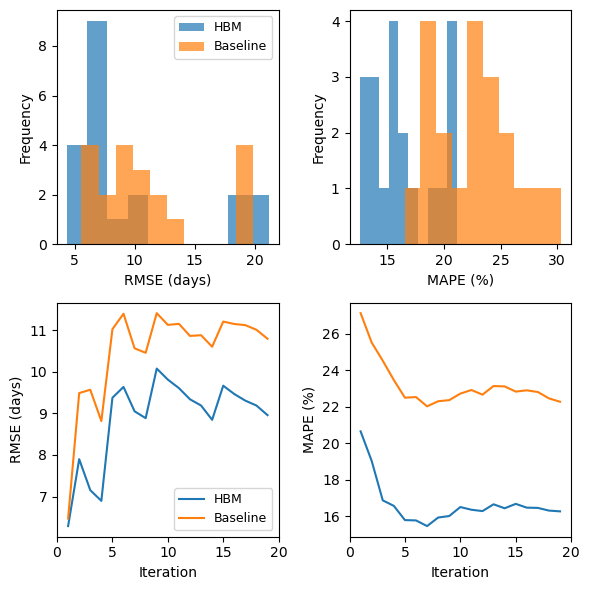

In [17]:
fig, axs=plt.subplots(2,2,figsize=(6,6))

axs[0,0].hist(hbm_rmse_list, alpha=0.7, label='HBM')
axs[0,0].hist(ridge_rmse_list, alpha=0.7, label='Baseline')
axs[0,0].set_xlabel('RMSE (days)')
axs[0,0].set_ylabel('Frequency')

axs[0,0].legend(fontsize=9)
axs[0,1].hist(hbm_mape_list, alpha=0.7)
axs[0,1].hist(ridge_mape_list, alpha=0.7)
axs[0,1].set_xlabel('MAPE (%)')
axs[0,1].set_ylabel('Frequency')


axs[1,0].plot(np.arange(L), rmse_mean_hbm, label='HBM')
axs[1,0].plot(np.arange(L), rmse_mean_base, label='Baseline')
axs[1,0].set_xticks([0,5,10,15,20])
axs[1,0].set_xlabel('Iteration')
axs[1,0].set_ylabel('RMSE (days)')
axs[1,0].legend(fontsize=9)

axs[1,1].plot(np.arange(L), np.array(mpe_mean_hbm), label='HBM')
axs[1,1].plot(np.arange(L), np.array(mpe_mean_base), label='Baseline')
axs[1,1].set_xticks([0,5,10,15,20])
axs[1,1].set_xlabel('Iteration')
axs[1,1].set_ylabel('MAPE (%)')

plt.tight_layout()
plt.savefig('kfolds_results.png', dpi=300)

In [18]:
y_test, y_pred, rmse_hbm, mape_hbm, _ = run_hbm_cv_fold(
            X_train_fold, y_train_fold, groups_train_fold, group_g,
            X_val_fold, y_val_fold, groups_val_fold
        )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [gamma_intercept, gamma_slope, sigma_theta, theta_raw, sigma_y]
Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 98 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [y_obs]


Output()

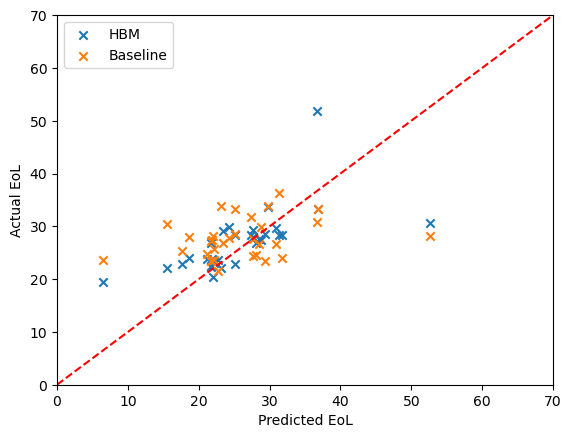

In [21]:
plt.scatter(y_test, y_pred, marker='x', label='HBM')
plt.scatter(y_test, y_pred_ridge, marker='x', label='Baseline')
plt.axline((0, 0), slope=1, color='red', linestyle='--')

plt.xlim(0, 70)
plt.ylim(0, 70)

plt.xlabel('Predicted EoL')
plt.ylabel('Actual EoL')

plt.legend()
plt.savefig('results_scatterplot.png', dpi=300)